In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# just for cleaner plots
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)

### renaming the columns according to out convinence

In [2]:
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root',
    'num_file_creations','num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate',
    'diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','attack_type','difficulty_level'
]

df = pd.read_csv('../data/raw/KDDTrain+.txt', header=None, names=columns)
df.drop('difficulty_level', axis=1, inplace=True)

print(f"Shape: {df.shape}")
df.head()

Shape: (125973, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [3]:
# data types and null check
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

In [4]:
# confirm no nulls
print("Null values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Null values: 0
Duplicate rows: 0


### mapping the output labels to give classes(for visualisation) 

In [5]:
# this mapping is ONLY for EDA plots
# the permanent version lives in 02_preprocessing.ipynb

attack_map = {
    'normal': 'Normal',
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS', 'apache2': 'DoS',
    'udpstorm': 'DoS', 'processtable': 'DoS', 'worm': 'DoS',
    'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe',
    'satan': 'Probe', 'mscan': 'Probe', 'saint': 'Probe',
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L',
    'multihop': 'R2L', 'phf': 'R2L', 'spy': 'R2L',
    'warezclient': 'R2L', 'warezmaster': 'R2L', 'sendmail': 'R2L',
    'named': 'R2L', 'snmpgetattack': 'R2L', 'snmpguess': 'R2L',
    'xlock': 'R2L', 'xsnoop': 'R2L', 'httptunnel': 'R2L',
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R',
    'rootkit': 'U2R', 'ps': 'U2R', 'sqlattack': 'U2R', 'xterm': 'U2R'
}

df['label'] = df['attack_type'].map(attack_map)

print(df['label'].value_counts())
print(f"\nUnique classes: {df['label'].nunique()}")

label
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

Unique classes: 5


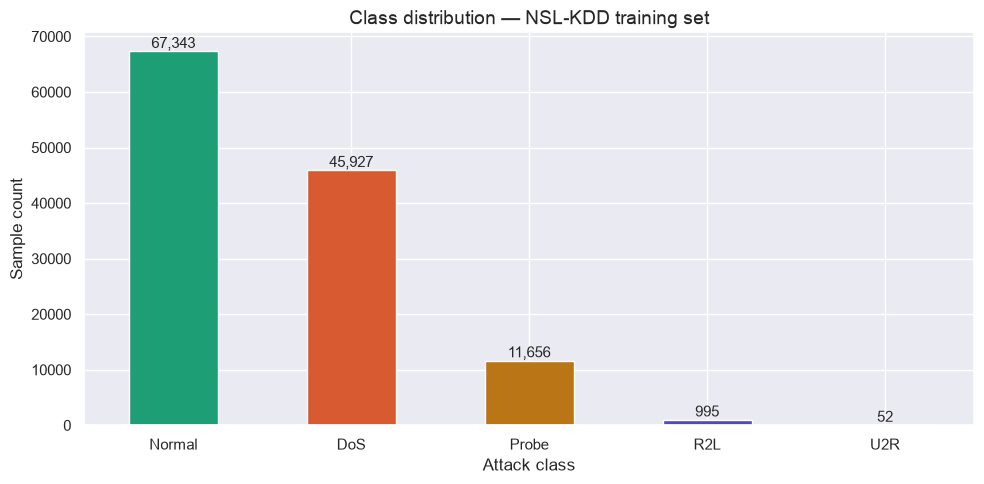


Why macro F1 matters:
If model predicts Normal every time → accuracy = 53.5%
That's meaningless. Macro F1 treats all 5 classes equally.


In [6]:
order = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']
colors = ['#1D9E75', '#D85A30', '#BA7517', '#534AB7', '#D4537E']

ax = df['label'].value_counts().reindex(order).plot(
    kind='bar', color=colors, edgecolor='white'
)

ax.set_title('Class distribution — NSL-KDD training set', fontsize=14)
ax.set_xlabel('Attack class')
ax.set_ylabel('Sample count')

# annotate each bar with count
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/class_distribution.png', dpi=150)
plt.show()

print("\nWhy macro F1 matters:")
print(f"If model predicts Normal every time → accuracy = "
      f"{df['label'].value_counts()['Normal'] / len(df) * 100:.1f}%")
print("That's meaningless. Macro F1 treats all 5 classes equally.")

### Protocol type by class 

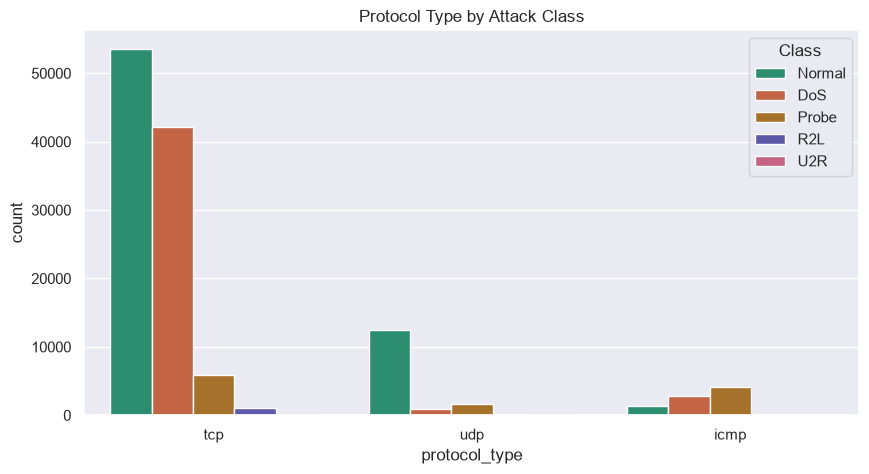

In [22]:
plt.figure(figsize=(10, 5))
sns.countplot(x='protocol_type', hue='label', data=df, hue_order=order, palette=colors)
plt.title('Protocol Type by Attack Class')
plt.legend(title='Class')
plt.savefig('../reports/Protocol_type_by_class.png', dpi=150)
plt.show()

### Top services by class

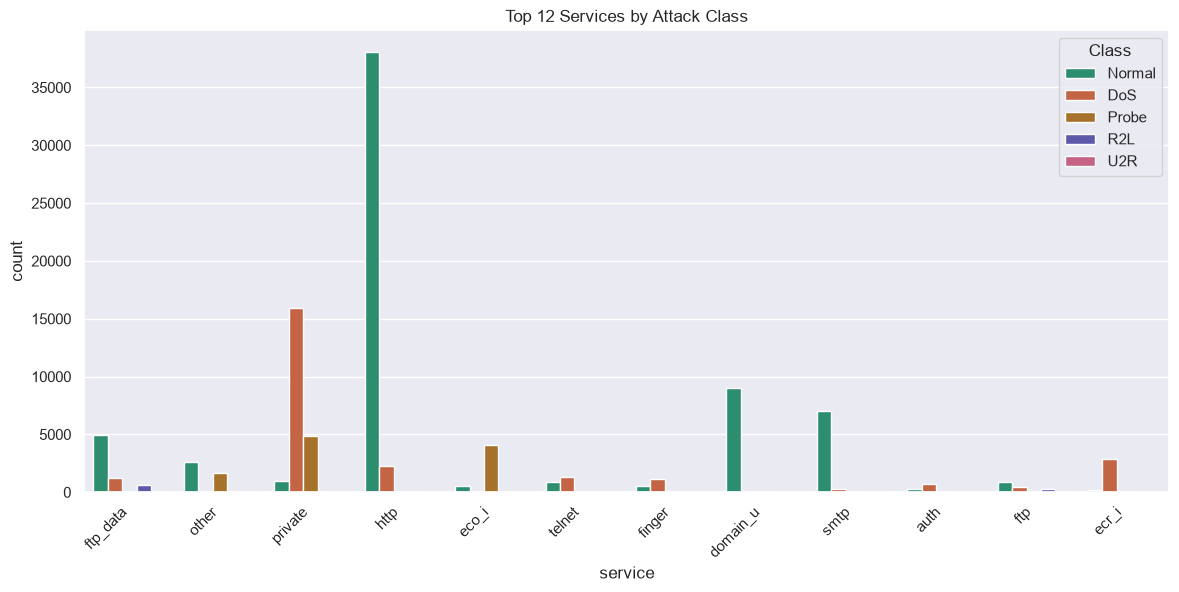

In [23]:
top_services = df['service'].value_counts().head(12).index
subset = df[df['service'].isin(top_services)]

plt.figure(figsize=(14, 6))
sns.countplot(x='service', hue='label', data=subset, hue_order=order, palette=colors)
plt.xticks(rotation=45, ha='right')
plt.title('Top 12 Services by Attack Class')
plt.savefig('../reports/Topservices_by_class.png', dpi=150)
plt.legend(title='Class')
plt.show()

### plot of src_bytes and dst_bytes 
These features help distinguish normal traffic from attacks because many attacks create unusual patterns in the amount of data being sent or received.

Using a log scale compresses the large values, making it easier to compare all attack classes on the same graph.

In [9]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,Normal
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,Normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,DoS
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,Normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,Normal


/var/folders/07/zkvtwz216_q7kwpfdzr_bj6m0000gn/T/ipykernel_58174/3642000798.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(order)
/var/folders/07/zkvtwz216_q7kwpfdzr_bj6m0000gn/T/ipykernel_58174/3642000798.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(order)


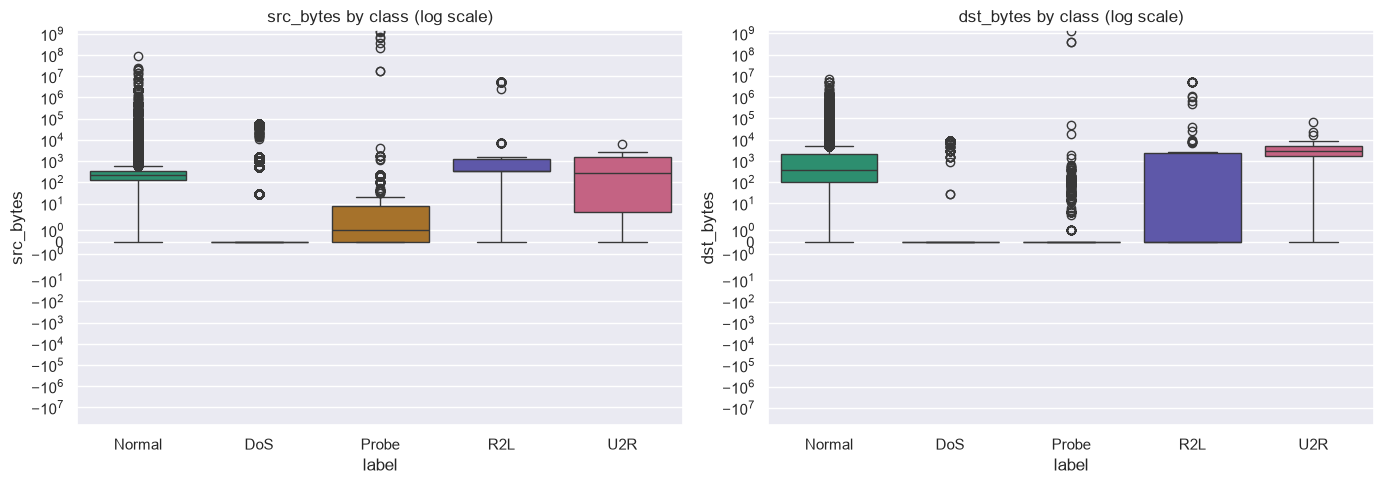

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['src_bytes', 'dst_bytes']): ## zip paris the axes and col together in pair (axes[0],src_bytes)
    sns.boxplot(x='label', y=col, data=df, order=order,
                hue='label', hue_order=order,
                palette=colors, legend=False, ax=ax)
    ax.set_yscale('symlog')
    ax.set_xticklabels(order)
    ax.set_title(f'{col} by class (log scale)')
plt.tight_layout()
plt.savefig('../reports/bytes_box_plot.png', dpi=150)
plt.show()

the above plot shows the number of bytes sent or recieved per connection and this exactly tells us that why do we need Xgboost in first place .
The src_bytes and dst_bytes shows very unusual network connection than normal traffic thus can be flagged as anamoly by autoencoder , but the plots of r2l and u2r is kind of similar to normal traffic thus requires labeles examples to get flagges correctly

###  Guest login vs class

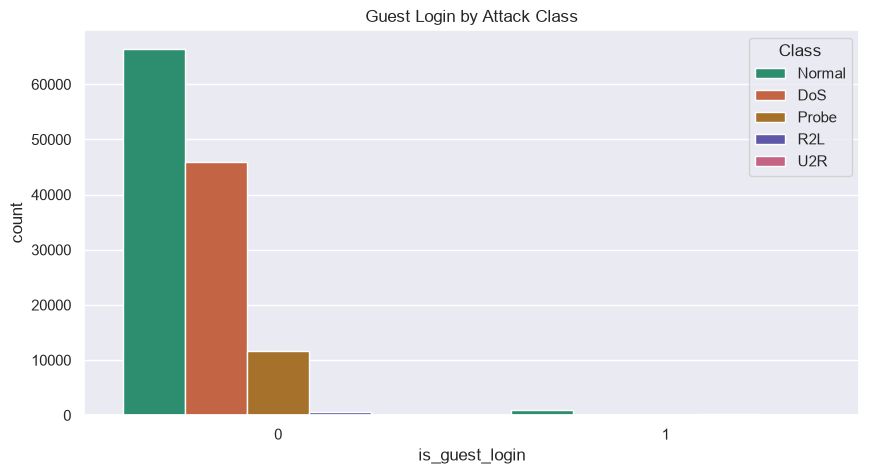

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(x='is_guest_login', hue='label', data=df, hue_order=order, palette=colors)
plt.title('Guest Login by Attack Class')
plt.legend(title='Class')
plt.show()

label
DoS        0.000000
Normal     1.296349
Probe      0.008579
R2L       31.457286
U2R        0.000000
Name: is_guest_login, dtype: float64


/var/folders/07/zkvtwz216_q7kwpfdzr_bj6m0000gn/T/ipykernel_58174/577527635.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=guest_pct.index, y=guest_pct.values, order=order, palette=colors)


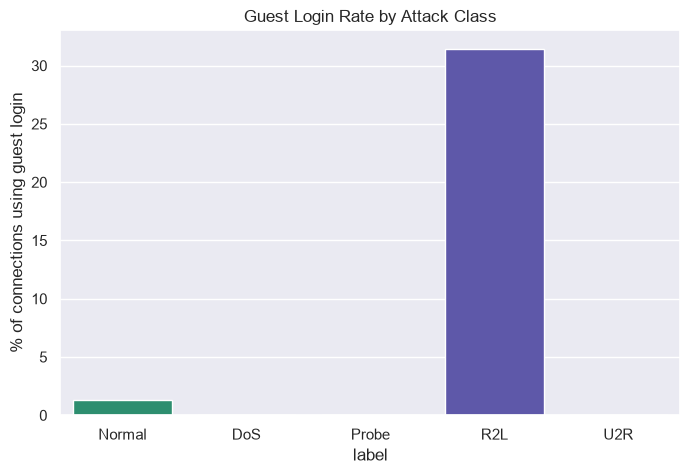

In [25]:
guest_pct = df.groupby('label')['is_guest_login'].mean() * 100
print(guest_pct)

plt.figure(figsize=(8,5))
sns.barplot(x=guest_pct.index, y=guest_pct.values, order=order, palette=colors)
plt.xticks(range(5), order)
plt.ylabel('% of connections using guest login')
plt.title('Guest Login Rate by Attack Class')
plt.savefig('../reports/Guest_login_by_class_percentage.png', dpi=150)
plt.show()

the above plot is conveying the information that percentage of the logins w.r.t guest login is significantly high in R2l 

### KDE of duration by flag 

/var/folders/07/zkvtwz216_q7kwpfdzr_bj6m0000gn/T/ipykernel_58174/1763658465.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.displot(data=df,x='duration',hue='flag',kind='kde',height=6,multiple='fill',clip=(0,None),palette='ch:rot=-.25,hue=1,light=.75')


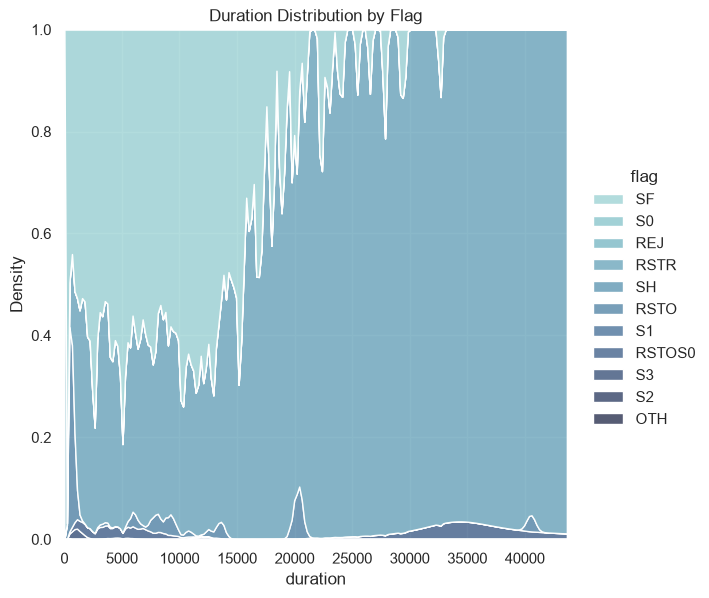

In [13]:
sns.displot(data=df,x='duration',hue='flag',kind='kde',height=6,multiple='fill',clip=(0,None),palette='ch:rot=-.25,hue=1,light=.75')
plt.title('Duration Distribution by Flag')
plt.show()

"Among all connections with this duration, what fraction belongs to each flag?"

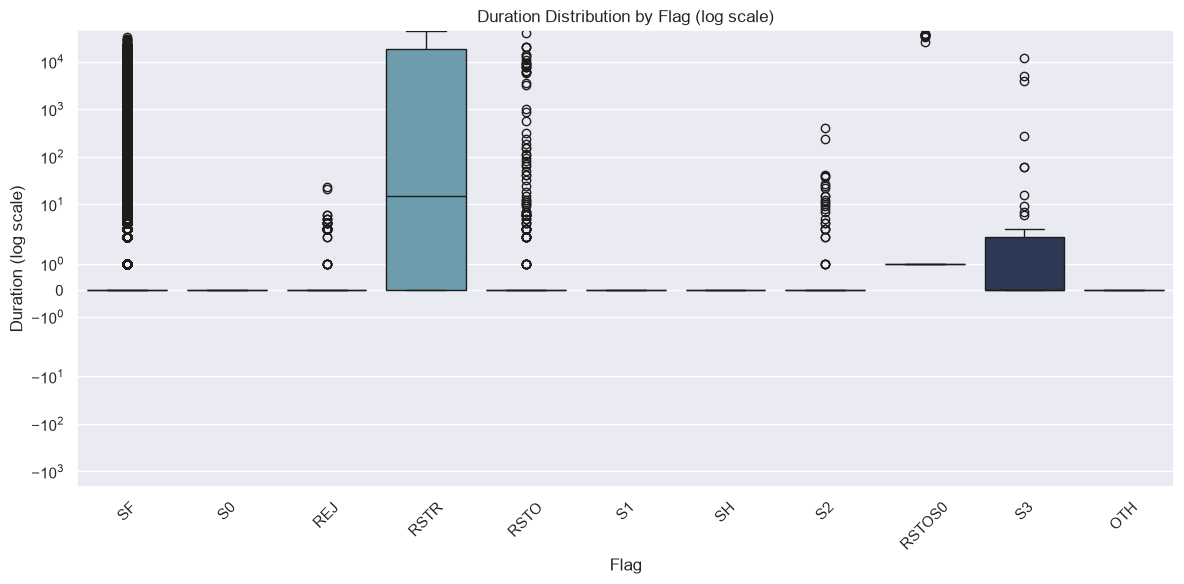

In [26]:
plt.figure(figsize=(12,6))
flag_order = df['flag'].value_counts().index.tolist()
sns.boxplot(x='flag', y='duration', data=df, order=flag_order,
            hue='flag', hue_order=flag_order, palette='ch:rot=-.25,hue=1,light=.75',
            legend=False)
plt.yscale('symlog')
plt.title('Duration Distribution by Flag (log scale)')
plt.xlabel('Flag')
plt.ylabel('Duration (log scale)')
plt.xticks(rotation=45)
plt.savefig('../reports/Duration_by_flag_box.png', dpi=150)
plt.tight_layout()
plt.show()

### Feature variance ranking

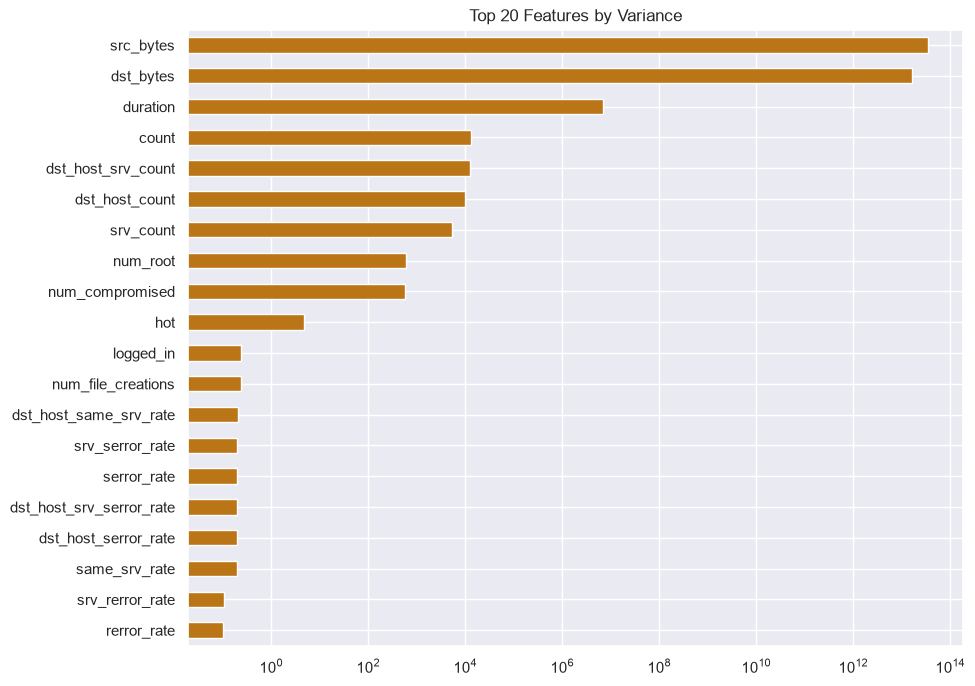

In [27]:
numeric_df = df.select_dtypes(include=[np.number]).copy()
variances = numeric_df.var().sort_values(ascending=False)
plt.figure(figsize=(10, 8))
ax=variances.head(20).plot(kind='barh', color=colors[2])
ax.set_xscale('log')
plt.title('Top 20 Features by Variance')
plt.savefig('../reports/feature_variance_ranking.png', dpi=150)
plt.gca().invert_yaxis()
plt.show()